# Notes:

This analysis only consider protein detected in LiPMS on control sample and RNA sequencing experiments

In [1]:
import sys
from datetime import datetime

import pandas as pd
import numpy as np
import scipy as sp
import scipy.stats as ss

import statsmodels as sm
from statsmodels.stats.contingency_tables import Table2x2
import statsmodels.formula.api as smf

import matplotlib as mpl
import matplotlib.pyplot as plt

from utils import *

In [2]:
# Date running analysis
RUN_START = datetime.now().astimezone()

print("=" * 50)
print("RUN START")
print("=" * 50)
print(f"{'date':12s}: {RUN_START.strftime('%Y-%m-%d')}")
print(f"{'time':12s}: {RUN_START.strftime('%H:%M:%S %Z')}")
print(f"{'iso':12s}: {RUN_START.isoformat()}")
print("=" * 50)


# Logging: software version
versions = {
    "python": sys.version.replace("\n", " "),
    "pandas": get_version(pd, "pandas"),
    "numpy": get_version(np, "numpy"),
    "scipy": get_version(sp, "scipy"),
    "matplotlib": get_version(mpl, "matplotlib"),
    "statsmodels": get_version(sm, "statsmodels"),
}

# Pretty print
print("Software versions:\n")
for k, v in versions.items():
    print(f"{k:12s}: {v}")

RUN START
date        : 2026-03-31
time        : 14:08:08 +07
iso         : 2026-03-31T14:08:08.898745+07:00
Software versions:

python      : 3.13.12 | packaged by conda-forge | (main, Feb  5 2026, 05:58:33) [Clang 19.1.7 ]
pandas      : 2.3.3
numpy       : 2.4.2
scipy       : 1.17.0
matplotlib  : 3.10.8
statsmodels : 0.14.6


In [3]:
# load custom setting for figures
set_nature_style()

In [4]:
# Logging: checksum input files
input_data = [
    '../data/protein_abundances/Protein_Abundance_control_sample.pkl',
    '../data/protein_abundances/SGD2Uniprot.pkl',
    '../data/protein_abundances/Normalization_factor.pkl',
    '../data/protein_abundances/Normalized_LiP_peptides_significant.pkl',
    '../data/protein_abundances/AF_Yeast_entanglement.pkl'
             ]
df_files = pd.DataFrame([
    file_info(f) for f in input_data
])

with pd.option_context("display.max_colwidth", None):
    display(df_files)

,path,size_bytes,sha256
0,../data/protein_abundances/Protein_Abundance_control_sample.pkl,885944,110a66c1cb47cbd3638d994fcc8249051f15ba17651860316a5bcff98492e8ae
1,../data/protein_abundances/SGD2Uniprot.pkl,62461,b59ab068c6f3a5b3f566cb34138acb4dc3c2796689f78d37a268442939a24425
2,../data/protein_abundances/Normalization_factor.pkl,120102,87c437b4d70322b344bc0e8512fafc839d377933a693e16bb91d408c696ae887
3,../data/protein_abundances/Normalized_LiP_peptides_significant.pkl,250675,4ffe88660f981540691c591c578843b35f267bd2b129aef1313eb2ee0dab0b6a
4,../data/protein_abundances/AF_Yeast_entanglement.pkl,11023900,685ba47126ff04649277cc8f4dcd19701fe3242fa6853441a17a58303f1b60e6


# Load data

In [5]:
df = pd.read_pickle('../data/protein_abundances/Protein_Abundance_control_sample.pkl')
SGD2Uni = pd.read_pickle('../data/protein_abundances/SGD2Uniprot.pkl')
# mRNA fold-change
normalization_factor = pd.read_pickle('../data/protein_abundances/Normalization_factor.pkl')
# LiP-data, peptide exhibit significant fold-change
df_lip = pd.read_pickle('../data/protein_abundances/Normalized_LiP_peptides_significant.pkl')
df_AF = pd.read_pickle('../data/protein_abundances/AF_Yeast_entanglement.pkl') #to get protein length
df_AF = df_AF.drop(columns=['fragment', 'uniprot_fragment', 'plddt', 'whGLN', 'entanglement_AF'])

In [6]:
# first 3 numbers are Old. last 3 numbers are Young
# Processing data
# 1. Drop column "Description"
df = df.drop(columns=["Description"])

# 2. Rename replicate columns
df = df.rename(columns={
    "Replicate 1": "O1",
    "Replicate 2": "O2",
    "Replicate 3": "O3",
    "Replicate 1.1": "Y1",
    "Replicate 2.1": "Y2",
    "Replicate 3.1": "Y3"
})
# 3. Drop rows where all replicate values are NaN
replicate_cols = ["O1", "O2", "O3", "Y1", "Y2", "Y3"]
df = df.dropna(subset=replicate_cols, how="any") #'any' or 'all' give similar results

In [7]:
df = df.merge(SGD2Uni[["SGDID", "Uniprot"]], on="SGDID", how="left")
# reorder columns
df = df[[
    "Accession",
    "SGDID",
    "Uniprot",
    "O1", "O2", "O3",
    "Y1", "Y2", "Y3"
]]

In [8]:
# ---- Compute Fold-change and p-value per row ----
def compute_stats(row):
    O = np.array([row["O1"], row["O2"], row["O3"]], dtype=float)
    Y = np.array([row["Y1"], row["Y2"], row["Y3"]], dtype=float)

    # handle case where all Y are 0
    if np.all(Y == 0):
        fc = 1
        p = 1
    else:
        fc = np.mean(O) / np.mean(Y)
        p = sp.stats.ttest_ind(O, Y, equal_var=False).pvalue
    return pd.Series([fc, p])

In [9]:
# compute FC and p-value
df[['FC', 'Pvalue']] = df.apply(compute_stats, axis=1)

df = df.merge(normalization_factor, on='Accession', how='inner')
df['FC_norm'] = df['FC']/df['NormFactor']
# df[df['NormFactor']!=1]
df

,Accession,SGDID,Uniprot,O1,O2,O3,Y1,Y2,Y3,FC,Pvalue,NormFactor,FC_norm
0,YPL019C,S000005940,Q02725,4.178885e+07,4.204768e+07,4.198175e+07,1.267989e+07,1.271294e+07,1.275959e+07,3.297780,1.242862e-06,1.0,3.297780
1,YNL121C,S000005065,P07213,1.750116e+07,1.663523e+07,1.679759e+07,9.744688e+06,8.954282e+06,9.057904e+06,1.835004,3.008348e-05,1.0,1.835004
2,YNL220W,S000005164,P80210,1.847388e+07,1.838129e+07,1.821648e+07,1.010788e+07,1.011520e+07,9.879726e+06,1.829452,1.708323e-07,1.0,1.829452
3,YNL302C,S000005246,P07281,2.520388e+08,2.304209e+08,2.246568e+08,5.629927e+08,5.403837e+08,5.387276e+08,0.430616,1.115359e-05,1.0,0.430616
4,YPL227C,S000006148,P40350,3.546039e+05,4.089249e+05,4.319773e+05,1.903457e+04,7.728805e+04,9.572053e+04,6.225195,5.064652e-04,1.0,6.225195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2567,YIL108W,S000001370,P40483,8.809438e+05,4.323921e+05,8.406757e+05,6.654727e+05,6.812586e+05,8.141677e+05,0.996813,9.890174e-01,1.0,0.996813
2568,YOR362C,S000005889,P21242,1.057500e+07,1.185353e+07,1.153441e+07,1.128266e+07,1.175196e+07,1.091369e+07,1.000431,9.920350e-01,1.0,1.000431
2569,YAR014C,S000000069,P27637,1.230791e+06,6.280753e+05,4.607515e+05,8.046273e+05,7.592260e+05,7.632091e+05,0.996801,9.925041e-01,1.0,0.996801
2570,YJL115W,S000003651,P32447,2.170228e+06,1.862165e+06,1.999362e+06,1.981641e+06,2.044287e+06,2.008224e+06,0.999603,9.937342e-01,1.0,0.999603


In [10]:
# merge entanglement
df = df.merge(df_AF[["Uniprot", "length_AF"]], on="Uniprot", how="inner")
df['length_z'] = (df['length_AF'] - df['length_AF'].mean())/df['length_AF'].std()
df

,Accession,SGDID,Uniprot,O1,O2,O3,Y1,Y2,Y3,FC,Pvalue,NormFactor,FC_norm,length_AF,length_z
0,YPL019C,S000005940,Q02725,4.178885e+07,4.204768e+07,4.198175e+07,1.267989e+07,1.271294e+07,1.275959e+07,3.297780,1.242862e-06,1.0,3.297780,835,0.899190
1,YNL121C,S000005065,P07213,1.750116e+07,1.663523e+07,1.679759e+07,9.744688e+06,8.954282e+06,9.057904e+06,1.835004,3.008348e-05,1.0,1.835004,617,0.307061
2,YNL220W,S000005164,P80210,1.847388e+07,1.838129e+07,1.821648e+07,1.010788e+07,1.011520e+07,9.879726e+06,1.829452,1.708323e-07,1.0,1.829452,433,-0.192718
3,YNL302C,S000005246,P07281,2.520388e+08,2.304209e+08,2.246568e+08,5.629927e+08,5.403837e+08,5.387276e+08,0.430616,1.115359e-05,1.0,0.430616,144,-0.977696
4,YPL227C,S000006148,P40350,3.546039e+05,4.089249e+05,4.319773e+05,1.903457e+04,7.728805e+04,9.572053e+04,6.225195,5.064652e-04,1.0,6.225195,334,-0.461621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2556,YIL108W,S000001370,P40483,8.809438e+05,4.323921e+05,8.406757e+05,6.654727e+05,6.812586e+05,8.141677e+05,0.996813,9.890174e-01,1.0,0.996813,696,0.521640
2557,YOR362C,S000005889,P21242,1.057500e+07,1.185353e+07,1.153441e+07,1.128266e+07,1.175196e+07,1.091369e+07,1.000431,9.920350e-01,1.0,1.000431,288,-0.586565
2558,YAR014C,S000000069,P27637,1.230791e+06,6.280753e+05,4.607515e+05,8.046273e+05,7.592260e+05,7.632091e+05,0.996801,9.925041e-01,1.0,0.996801,709,0.556950
2559,YJL115W,S000003651,P32447,2.170228e+06,1.862165e+06,1.999362e+06,1.981641e+06,2.044287e+06,2.008224e+06,0.999603,9.937342e-01,1.0,0.999603,279,-0.611011


In [11]:
# extract SC from LiPMS (without plddt info)
df_lip = df_lip.merge(SGD2Uni, on='SGDID', how='left')
SC_proteins = df_lip['Uniprot'].unique().tolist()
df_lip

,peptides,proteotypicity,trypticity,Start AA,End AA,Protein name,Description,Protein abundance change old/young,Normalized peptide abundance ratio old/young,qvalue old/young,SGDID,Uniprot
0,RPTSAYFLYLQDHR,1,FT,44,59,ABF2,"ABF2 SGDID:S000004676, Chr XIII from 411569-41...",1.000000,1249.384890,0.011246,S000004676,Q02486
1,VSAIFSTPLQHIVELESK,1,FT,998,1017,ACC1,"ACC1 SGDID:S000005299, Chr XIV from 661374-654...",2.022110,16.616413,0.008208,S000005299,Q00955
2,IGSFGPQEDEFFNKVTEYAR,1,FT,1592,1613,ACC1,"ACC1 SGDID:S000005299, Chr XIV from 661374-654...",2.022110,65.122841,0.031076,S000005299,Q00955
3,AIQVEGQPIILT,1,HT,1745,1758,ACC1,"ACC1 SGDID:S000005299, Chr XIV from 661374-654...",2.022110,0.188901,0.012240,S000005299,Q00955
4,EGVTVPIVEWK,1,HT,1121,1133,ACC1,"ACC1 SGDID:S000005299, Chr XIV from 661374-654...",2.022110,0.137421,0.028971,S000005299,Q00955
...,...,...,...,...,...,...,...,...,...,...,...,...
1267,NNLGYSKDQVFKF,1,HT,289,303,MCR1,"MCR1 SGDID:S000001633, Chr XI from 166544-1674...",1.000000,0.159863,0.024164,S000001633,P36060
1268,DIANRIGYI,1,HT,133,143,RPL25,"RPL25 SGDID:S000005487, Chr XV from 80348-8036...",0.656078,0.136421,0.010854,S000005487,P04456
1269,AKIAALAGQQ,1,HT,287,298,RPL5,"RPL5 SGDID:S000006052, Chr XVI from 303121-304...",3.385618,0.113018,0.012452,S000006052,P26321
1270,GGNLDMGDFKENDEEDEEEEIEPEVKA,1,HT,189,217,SBA1,"SBA1 SGDID:S000001600, Chr XI from 220324-2209...",0.764479,9.440744,0.023145,S000001600,P28707


In [12]:
len(SC_proteins)

468

In [13]:
# add SC back to df
df['SC']= df['Uniprot'].isin(SC_proteins).astype(int)
df

,Accession,SGDID,Uniprot,O1,O2,O3,Y1,Y2,Y3,FC,Pvalue,NormFactor,FC_norm,length_AF,length_z,SC
0,YPL019C,S000005940,Q02725,4.178885e+07,4.204768e+07,4.198175e+07,1.267989e+07,1.271294e+07,1.275959e+07,3.297780,1.242862e-06,1.0,3.297780,835,0.899190,1
1,YNL121C,S000005065,P07213,1.750116e+07,1.663523e+07,1.679759e+07,9.744688e+06,8.954282e+06,9.057904e+06,1.835004,3.008348e-05,1.0,1.835004,617,0.307061,0
2,YNL220W,S000005164,P80210,1.847388e+07,1.838129e+07,1.821648e+07,1.010788e+07,1.011520e+07,9.879726e+06,1.829452,1.708323e-07,1.0,1.829452,433,-0.192718,1
3,YNL302C,S000005246,P07281,2.520388e+08,2.304209e+08,2.246568e+08,5.629927e+08,5.403837e+08,5.387276e+08,0.430616,1.115359e-05,1.0,0.430616,144,-0.977696,0
4,YPL227C,S000006148,P40350,3.546039e+05,4.089249e+05,4.319773e+05,1.903457e+04,7.728805e+04,9.572053e+04,6.225195,5.064652e-04,1.0,6.225195,334,-0.461621,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2556,YIL108W,S000001370,P40483,8.809438e+05,4.323921e+05,8.406757e+05,6.654727e+05,6.812586e+05,8.141677e+05,0.996813,9.890174e-01,1.0,0.996813,696,0.521640,0
2557,YOR362C,S000005889,P21242,1.057500e+07,1.185353e+07,1.153441e+07,1.128266e+07,1.175196e+07,1.091369e+07,1.000431,9.920350e-01,1.0,1.000431,288,-0.586565,0
2558,YAR014C,S000000069,P27637,1.230791e+06,6.280753e+05,4.607515e+05,8.046273e+05,7.592260e+05,7.632091e+05,0.996801,9.925041e-01,1.0,0.996801,709,0.556950,0
2559,YJL115W,S000003651,P32447,2.170228e+06,1.862165e+06,1.999362e+06,1.981641e+06,2.044287e+06,2.008224e+06,0.999603,9.937342e-01,1.0,0.999603,279,-0.611011,0


In [14]:
# df['log2FC'] = np.log2(df['FC_norm'])
eps = 1e-6 #add a small value to avoid get log of 0
df['log2FC'] = np.log2(df['FC_norm'] + eps)
df["Abd_up"] = ((df["FC_norm"] > 1) & (df["Pvalue"] < 0.01)).astype(int)

# Get OR using contingency table

Abd_up    Abd_up = Yes  Abd_up = No
SC                                 
SC = Yes           165          288
SC = No            594         1514
Crude Odds Ratio: 1.460
95% CI: [1.179, 1.808]
Fisher exact P-value: 0.0006543737472406346
--------------------------------------------------


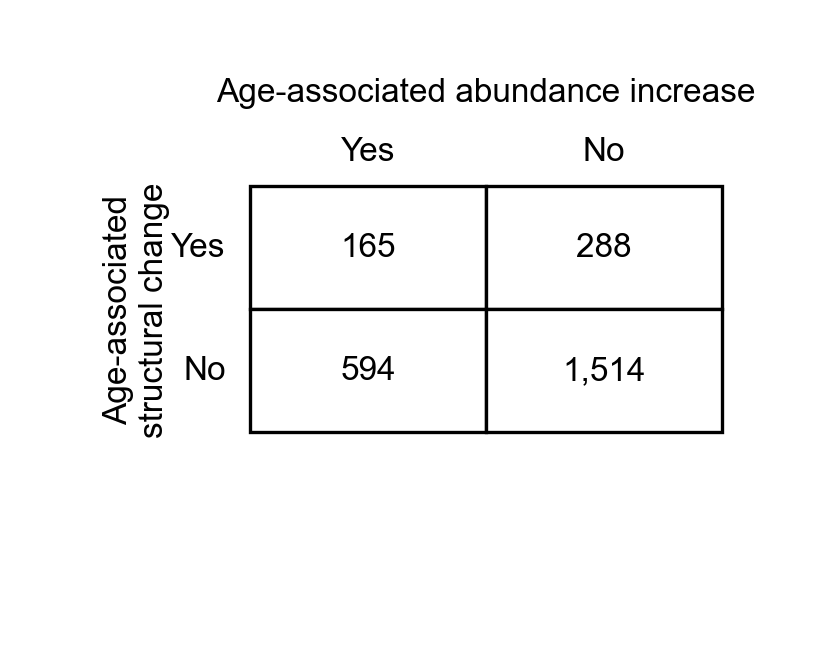

In [15]:
# build contingency table: Yes first, then No
contingency = (
    pd.crosstab(
        df["SC"],
        df["Abd_up"]
    )
    .reindex(index=[1, 0], columns=[1, 0])   # <-- this enforces Yes first
    .rename(
        index={1: "SC = Yes", 0: "SC = No"},
        columns={1: "Abd_up = Yes", 0: "Abd_up = No"},
    )
)
print(contingency)

# convert to numpy array in [[a,b],[c,d]] format
table = contingency.to_numpy()

ct = Table2x2(table)

odds_ratio, pvalue = ss.fisher_exact(table)
ci_low, ci_high = ct.oddsratio_confint(alpha=0.05, method="exact")
print(f"Crude Odds Ratio: {odds_ratio:.3f}")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Fisher exact P-value: {pvalue}")
print('-'*50)

fig, ax = draw_contingency_table(
    table,
    title_top="Age-associated abundance increase",
    title_left="Age-associated\nstructural change",
)
fig.savefig('figs/SC_Abundance_increase_contingency_table.pdf')
fig.savefig('figs/SC_Abundance_increase_contingency_table.png', dpi=300)
# print("p-value:", pval)


# Logistic Regression

In [16]:
model = smf.logit('Abd_up ~ SC+length_z', data=df)
result = model.fit()
print(result.summary())

summary_df = summarize_logit(result)
print(summary_df.to_string(float_format=lambda x: f"{x:.3f}"))


Optimization terminated successfully.
         Current function value: 0.598620
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 Abd_up   No. Observations:                 2561
Model:                          Logit   Df Residuals:                     2558
Method:                           MLE   Df Model:                            2
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.01503
Time:                        14:08:12   Log-Likelihood:                -1533.1
converged:                       True   LL-Null:                       -1556.5
Covariance Type:            nonrobust   LLR p-value:                 6.902e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9534      0.049    -19.455      0.000      -1.049      -0.857
SC             0.4167      0.

In [17]:
# df.to_pickle('protein_abundance_normalized.pkl')

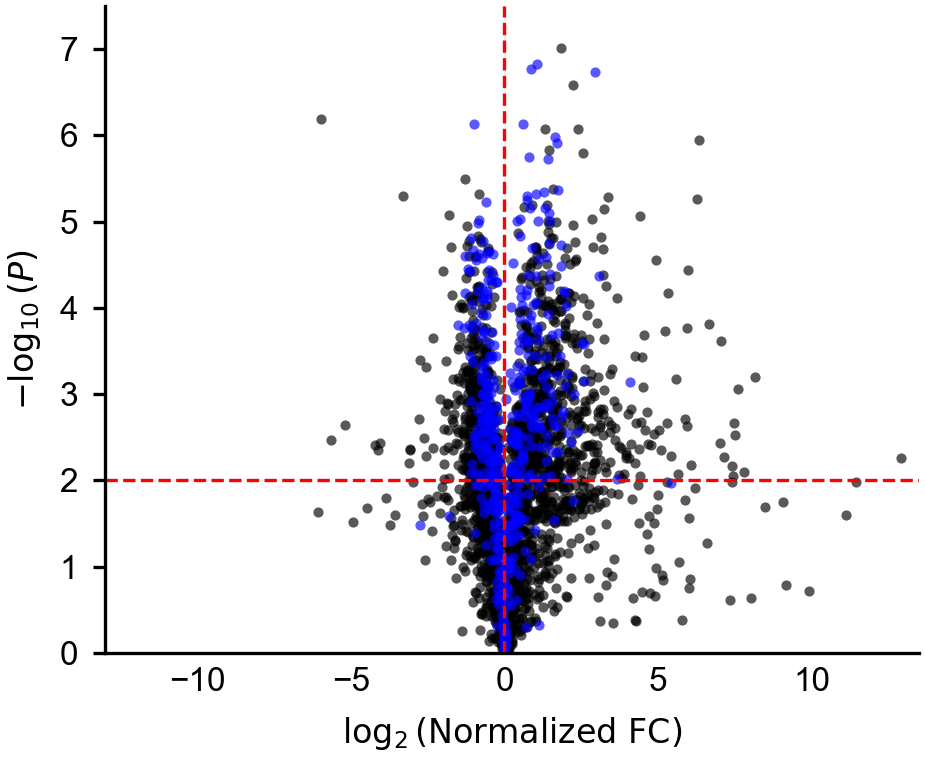

In [18]:
fig_v, ax_v = plot_volcano_lip(df)
plt.show()
fig_v.savefig('figs/SC_Abundance_increase_Volcano.pdf')
fig_v.savefig('figs/SC_Abundance_increase_Volcano.png', dpi=300)

In [19]:
RUN_END = datetime.now().astimezone()

print("\n" + "=" * 50)
print("RUN END")
print("=" * 50)
print(f"{'date':12s}: {RUN_END.strftime('%Y-%m-%d')}")
print(f"{'time':12s}: {RUN_END.strftime('%H:%M:%S %Z')}")
print(f"{'iso':12s}: {RUN_END.isoformat()}")

# Duration
duration = RUN_END - RUN_START
print(f"{'duration':12s}: {str(duration).split('.')[0]}")  # remove microseconds

print("=" * 50)


RUN END
date        : 2026-03-31
time        : 14:08:13 +07
iso         : 2026-03-31T14:08:13.097136+07:00
duration    : 0:00:04
